# End-to-End MLOps Pipeline

**Goal:** Building a production-grade ML pipeline with experiment tracking, hyperparameter optimization, and a REST API with full ML lifecycle.

**Dataset:** Telco Customer Churn (Kaggle) which predicts which customers will leave

---

### Steps:
1. Data preprocessing pipeline (ColumnTransformer)
2. Experiment tracking with MLflow (log params, metrics, models)
3. Hyperparameter optimization with Optuna (50 trials)
4. Model registry and versioning
5. Best model evaluation with detailed metrics
6. FastAPI REST endpoint for serving predictions
7. Docker-ready project structure



### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
import json
import time
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve)
import xgboost as xgb
import lightgbm as lgb

import mlflow
import mlflow.sklearn
import optuna
import fastapi
import uvicorn

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print(f"MLflow version: {mlflow.__version__}")
print(f"Optuna version: {optuna.__version__}")
print("All libraries loaded!")

MLflow version: 3.10.1
Optuna version: 4.7.0
All libraries loaded!


### Step 2: Load & Explore Dataset

https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [2]:
# Load data
df = pd.read_csv('Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset: {df.shape[0]} customers, {df.shape[1]} columns")
print(f"\nTarget: Churn")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")
print(f"\nColumn types:")
print(df.dtypes.value_counts())
df.head()

Dataset: 7043 customers, 21 columns

Target: Churn
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%

Column types:
object     18
int64       2
float64     1
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


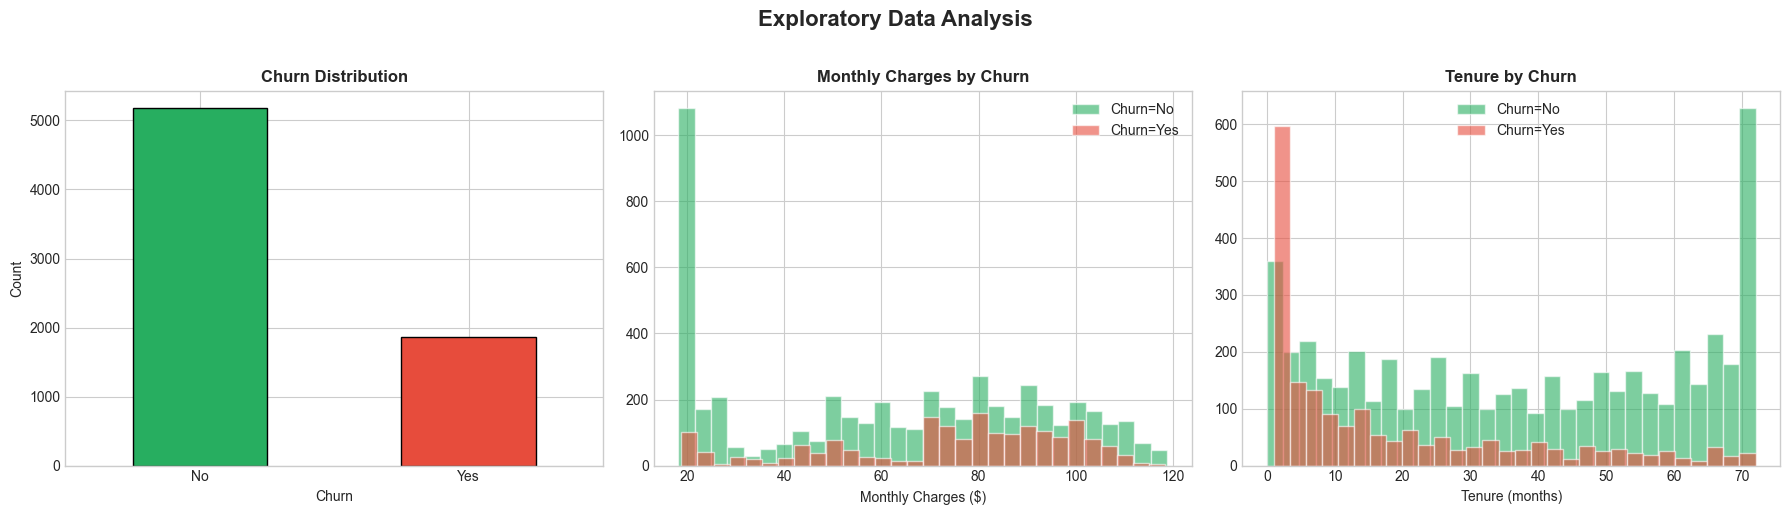

Key observations:
  Customers who churn tend to have HIGHER monthly charges
  Customers who churn tend to have SHORTER tenure (new customers leave faster)


In [3]:
# EDA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Churn distribution
df['Churn'].value_counts().plot.bar(ax=axes[0], color=['#27AE60', '#E74C3C'], edgecolor='black')
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Monthly charges by churn
for label, color in [('No', '#27AE60'), ('Yes', '#E74C3C')]:
    subset = df[df['Churn'] == label]['MonthlyCharges']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}', edgecolor='white')
axes[1].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].legend()

# Tenure by churn
for label, color in [('No', '#27AE60'), ('Yes', '#E74C3C')]:
    subset = df[df['Churn'] == label]['tenure']
    axes[2].hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}', edgecolor='white')
axes[2].set_title('Tenure by Churn', fontweight='bold')
axes[2].set_xlabel('Tenure (months)')
axes[2].legend()

plt.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  Customers who churn tend to have HIGHER monthly charges")
print("  Customers who churn tend to have SHORTER tenure (new customers leave faster)")

### Step 3: Data Preprocessing Pipeline

In [4]:
# Fix TotalCharges (has spaces that should be numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID (not a feature)
df.drop('customerID', axis=1, inplace=True)

# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Feature engineering
df['AvgChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)
df['TenureBin'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-12', '13-24', '25-48', '49-72'])
df['HasMultipleServices'] = ((df['PhoneService'] == 'Yes') & (df['InternetService'] != 'No')).astype(int)

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify column types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Churn rate (train): {y_train.mean()*100:.1f}% | (test): {y_test.mean()*100:.1f}%")
print("\nPreprocessing pipeline ready!")

Numeric features (6): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargesPerMonth', 'HasMultipleServices']
Categorical features (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureBin']

Train: 5634 | Test: 1409
Churn rate (train): 26.5% | (test): 26.5%

Preprocessing pipeline ready!


### Step 4: MLflow Experiment Tracking

MLflow logs every experiment so can compare models, reproduce results, and track what works.

In [5]:
# Set up MLflow
mlflow.set_tracking_uri('mlruns')  # local storage
EXPERIMENT_NAME = 'churn-prediction'
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow experiment: {EXPERIMENT_NAME}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"\nTo view the MLflow dashboard, run in terminal:")
print(f"  mlflow ui")
print(f"Then open: http://localhost:5000")

MLflow experiment: churn-prediction
Tracking URI: mlruns

To view the MLflow dashboard, run in terminal:
  mlflow ui
Then open: http://localhost:5000


In [6]:
# Helper function: train model and log everything to MLflow
def train_and_log(model, model_name, X_train, X_test, y_train, y_test, preprocessor, extra_params=None):
    """Train a model inside a sklearn Pipeline, evaluate, and log to MLflow."""
    
    # Build pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    with mlflow.start_run(run_name=model_name):
        # Train
        t0 = time.time()
        pipeline.fit(X_train, y_train)
        train_time = time.time() - t0
        
        # Predict
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 0
        
        # Log to MLflow
        mlflow.log_param('model_name', model_name)
        mlflow.log_param('train_size', len(X_train))
        mlflow.log_param('test_size', len(X_test))
        if extra_params:
            mlflow.log_params(extra_params)
        
        mlflow.log_metric('accuracy', acc)
        mlflow.log_metric('f1_score', f1)
        mlflow.log_metric('precision', prec)
        mlflow.log_metric('recall', rec)
        mlflow.log_metric('auc', auc)
        mlflow.log_metric('train_time_seconds', train_time)
        
        # Log model
        mlflow.sklearn.log_model(pipeline, 'model')
        
        # Log run ID
        run_id = mlflow.active_run().info.run_id
        
        print(f"  {model_name:25s} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | Time: {train_time:.1f}s | Run: {run_id[:8]}")
    
    return {'name': model_name, 'accuracy': acc, 'f1': f1, 'auc': auc, 
            'precision': prec, 'recall': rec, 'pipeline': pipeline, 'run_id': run_id}

### Step 5: Train Baseline Models (All Logged to MLflow)

In [7]:
print("Training baseline models (all tracked in MLflow)...")
print("="*90)

baseline_results = []

# Logistic Regression
result = train_and_log(
    LogisticRegression(max_iter=1000, random_state=42),
    'LogisticRegression', X_train, X_test, y_train, y_test, preprocessor,
    extra_params={'C': 1.0, 'max_iter': 1000}
)
baseline_results.append(result)

# Random Forest
result = train_and_log(
    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'RandomForest', X_train, X_test, y_train, y_test, preprocessor,
    extra_params={'n_estimators': 200, 'max_depth': 10}
)
baseline_results.append(result)

# Gradient Boosting
result = train_and_log(
    GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    'GradientBoosting', X_train, X_test, y_train, y_test, preprocessor,
    extra_params={'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5}
)
baseline_results.append(result)

# XGBoost
result = train_and_log(
    xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, 
                       eval_metric='logloss', verbosity=0, random_state=42),
    'XGBoost', X_train, X_test, y_train, y_test, preprocessor,
    extra_params={'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5}
)
baseline_results.append(result)

# LightGBM
result = train_and_log(
    lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                        verbosity=-1, random_state=42),
    'LightGBM', X_train, X_test, y_train, y_test, preprocessor,
    extra_params={'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5}
)
baseline_results.append(result)

print("\nAll baseline models trained and logged to MLflow!")
print(f"Total runs: {len(baseline_results)}")

Training baseline models (all tracked in MLflow)...


2026/03/26 16:39:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 16:39:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LogisticRegression        | Acc: 0.8048 | F1: 0.5889 | AUC: 0.8467 | Time: 0.1s | Run: 0241bf9a


2026/03/26 16:39:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 16:39:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  RandomForest              | Acc: 0.8006 | F1: 0.5849 | AUC: 0.8396 | Time: 1.0s | Run: 1f97571a


...

  GradientBoosting          | Acc: 0.7963 | F1: 0.5859 | AUC: 0.8326 | Time: 3.3s | Run: 618d6615


2026/03/26 16:39:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 16:39:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  XGBoost                   | Acc: 0.7942 | F1: 0.5748 | AUC: 0.8310 | Time: 1.1s | Run: ca9254e4


2026/03/26 16:39:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 16:39:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LightGBM                  | Acc: 0.7984 | F1: 0.5872 | AUC: 0.8324 | Time: 1.6s | Run: 495a0996

All baseline models trained and logged to MLflow!
Total runs: 5


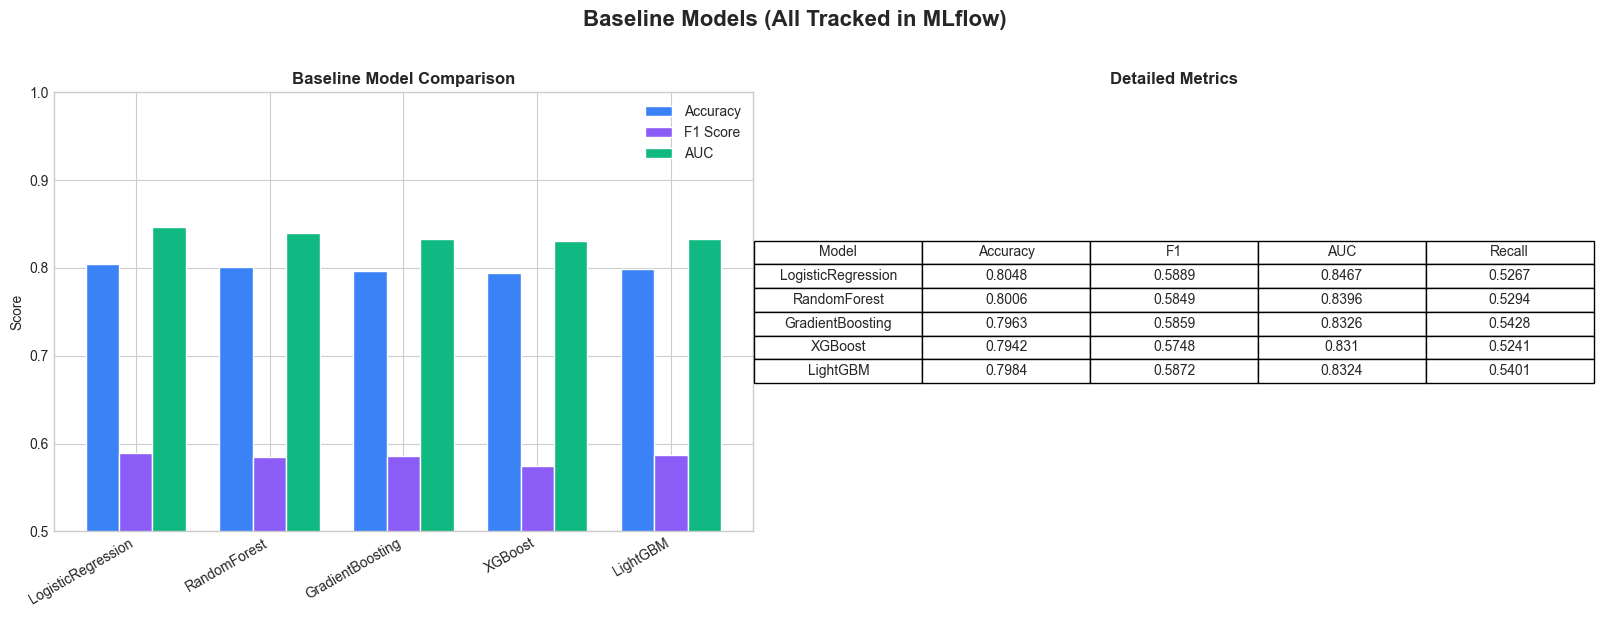


Best baseline: LogisticRegression (F1=0.5889)


In [8]:
# Visualize baseline comparison
results_df = pd.DataFrame(baseline_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
x = np.arange(len(results_df))
width = 0.25
axes[0].bar(x - width, results_df['accuracy'], width, label='Accuracy', color='#3B82F6', edgecolor='white')
axes[0].bar(x, results_df['f1'], width, label='F1 Score', color='#8B5CF6', edgecolor='white')
axes[0].bar(x + width, results_df['auc'], width, label='AUC', color='#10B981', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['name'], rotation=30, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('Baseline Model Comparison', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)

# Table
axes[1].axis('off')
table_data = results_df[['name', 'accuracy', 'f1', 'auc', 'recall']].round(4).values
table = axes[1].table(cellText=table_data,
                       colLabels=['Model', 'Accuracy', 'F1', 'AUC', 'Recall'],
                       loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
axes[1].set_title('Detailed Metrics', fontweight='bold')

plt.suptitle('Baseline Models (All Tracked in MLflow)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_baseline = max(baseline_results, key=lambda x: x['f1'])
print(f"\nBest baseline: {best_baseline['name']} (F1={best_baseline['f1']:.4f})")

### Step 6: Hyperparameter Optimization with Optuna

Optuna automatically searches for the best hyperparameters using Bayesian optimization it will be much smarter than grid search.

In [9]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    """Optuna objective: maximize F1 score with 5-fold CV."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }
    
    model = xgb.XGBClassifier(**params, eval_metric='logloss', verbosity=0, random_state=42)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    
    # Log each trial to MLflow
    with mlflow.start_run(run_name=f'optuna_trial_{trial.number}', nested=True):
        mlflow.log_params(params)
        mlflow.log_metric('cv_f1_mean', scores.mean())
        mlflow.log_metric('cv_f1_std', scores.std())
    
    return scores.mean()

# Run optimization
print("Running Optuna hyperparameter optimization (50 trials)...")
print("Each trial is logged to MLflow.\n")

with mlflow.start_run(run_name='optuna_optimization'):
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    
    mlflow.log_params(study.best_params)
    mlflow.log_metric('best_cv_f1', study.best_value)

print(f"\nBest trial: #{study.best_trial.number}")
print(f"   Best CV F1: {study.best_value:.4f}")
print(f"   Best params:")
for k, v in study.best_params.items():
    print(f"     {k}: {v}")

Running Optuna hyperparameter optimization (50 trials)...
Each trial is logged to MLflow.



  0%|          | 0/50 [00:00<?, ?it/s]


Best trial: #43
   Best CV F1: 0.5916
   Best params:
     n_estimators: 365
     max_depth: 3
     learning_rate: 0.03259615359119851
     subsample: 0.7647397857092466
     colsample_bytree: 0.5347945423368622
     reg_alpha: 9.769843137822406
     reg_lambda: 0.1356720260432223
     min_child_weight: 9


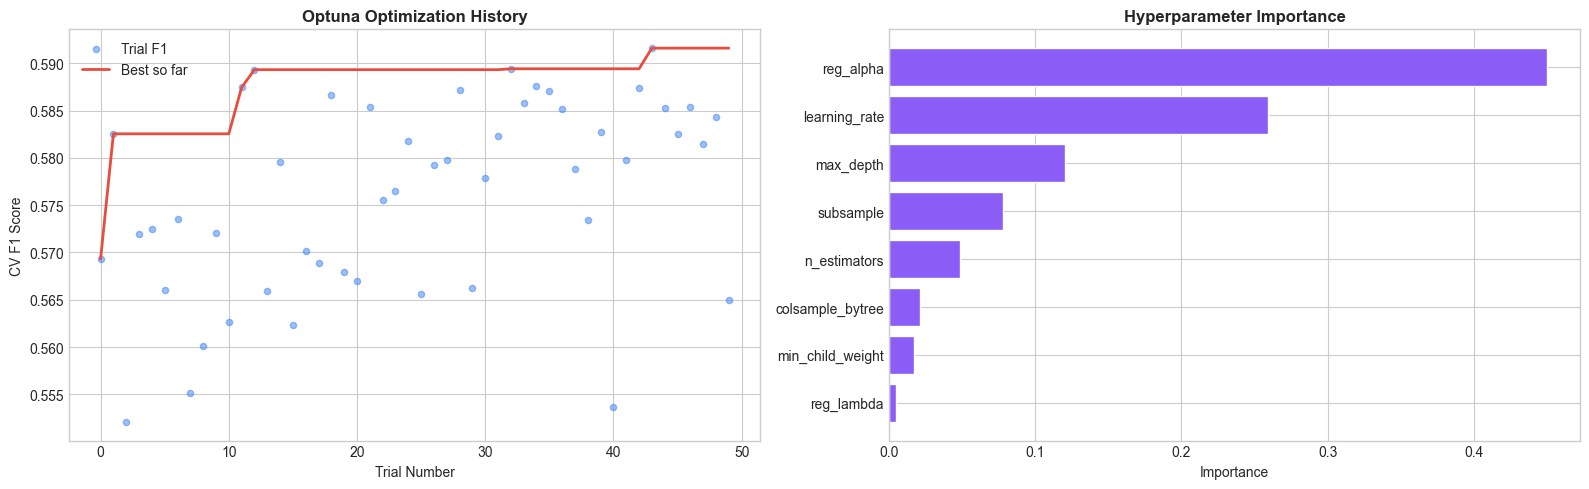

In [10]:
# Visualize optimization history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Optimization history
trials = study.trials
trial_numbers = [t.number for t in trials]
trial_values = [t.value for t in trials]
best_so_far = [max(trial_values[:i+1]) for i in range(len(trial_values))]

axes[0].scatter(trial_numbers, trial_values, alpha=0.5, color='#3B82F6', s=20, label='Trial F1')
axes[0].plot(trial_numbers, best_so_far, color='#E74C3C', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('CV F1 Score')
axes[0].set_title('Optuna Optimization History', fontweight='bold')
axes[0].legend()

# Parameter importance
importances = optuna.importance.get_param_importances(study)
params_sorted = sorted(importances.items(), key=lambda x: x[1], reverse=True)
axes[1].barh([p[0] for p in params_sorted], [p[1] for p in params_sorted], color='#8B5CF6', edgecolor='white')
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importance', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Why Optuna was applied to XGBoost and not LogReg:
 * LogReg has ~2 tunable parameters (C, penalty) a simple grid search would cover.
 * XGBoost has 8+ interacting parameters where Bayesian optimization adds real value.
 * Baseline LogReg (F1=0.5889) was already near its ceiling with default settings.
 * Baseline XGBoost (F1=0.5748) had significant room for improvement with tuning.

### Step 7: Train Best Model & Evaluate

In [11]:
# Train final model with best params
best_model = xgb.XGBClassifier(**study.best_params, eval_metric='logloss', verbosity=0, random_state=42)

result_best = train_and_log(
    best_model, 'XGBoost_Optimized', 
    X_train, X_test, y_train, y_test, preprocessor,
    extra_params=study.best_params
)

print(f"\nOptimized XGBoost Results:")
print(f"  Accuracy:  {result_best['accuracy']:.4f}")
print(f"  F1 Score:  {result_best['f1']:.4f}")
print(f"  AUC:       {result_best['auc']:.4f}")
print(f"  Precision: {result_best['precision']:.4f}")
print(f"  Recall:    {result_best['recall']:.4f}")

# Improvement over baseline
baseline_f1 = [r['f1'] for r in baseline_results if r['name'] == 'XGBoost'][0]
improvement = (result_best['f1'] - baseline_f1) * 100
print(f"\n  Improvement over baseline XGBoost: +{improvement:.2f}% F1")

2026/03/26 16:41:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 16:41:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  XGBoost_Optimized         | Acc: 0.8055 | F1: 0.5947 | AUC: 0.8493 | Time: 0.2s | Run: 11b9ae48

Optimized XGBoost Results:
  Accuracy:  0.8055
  F1 Score:  0.5947
  AUC:       0.8493
  Precision: 0.6656
  Recall:    0.5374

  Improvement over baseline XGBoost: +1.99% F1


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.67      0.54      0.59       374

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



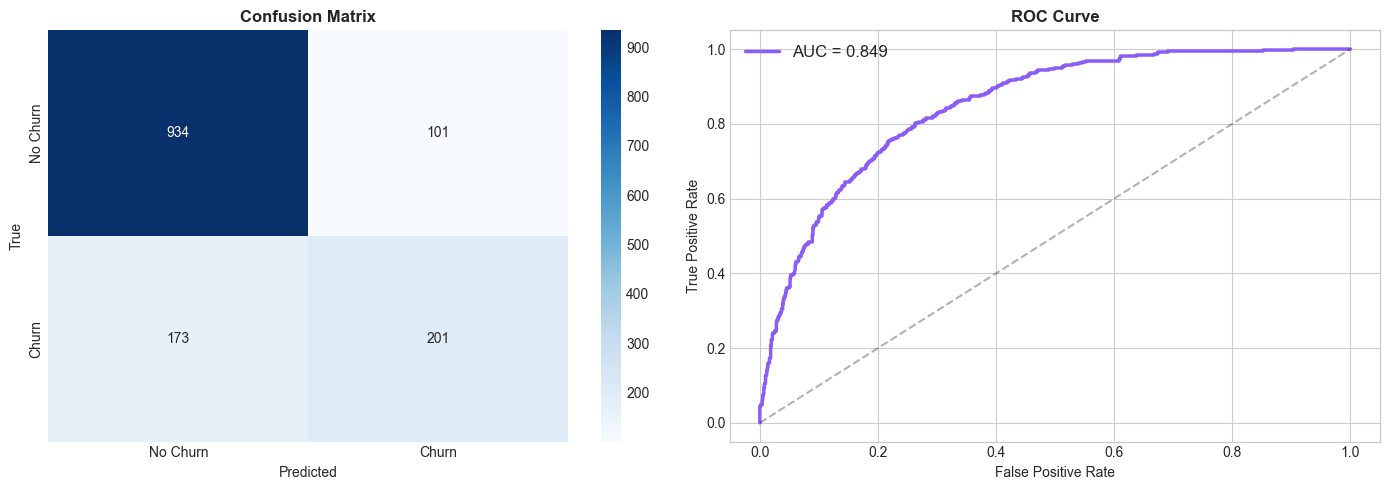

In [12]:
# Detailed evaluation
best_pipeline = result_best['pipeline']
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#8B5CF6', linewidth=2.5, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

### Step 8: Save Best Model for Deployment

In [13]:
# Save the best pipeline
MODEL_PATH = 'best_model.pkl'
joblib.dump(best_pipeline, MODEL_PATH)
model_size = os.path.getsize(MODEL_PATH) / (1024*1024)

print(f"Best model saved: {MODEL_PATH} ({model_size:.1f} MB)")

# Also save the feature names for the API
feature_info = {
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'all_columns': list(X.columns)
}
with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print(f"Feature info saved: feature_info.json")

# Verify it loads correctly
loaded_model = joblib.load(MODEL_PATH)
test_pred = loaded_model.predict(X_test[:5])
print(f"\nVerification - first 5 predictions: {test_pred}")
print(f"Match original: {np.array_equal(test_pred, best_pipeline.predict(X_test[:5]))}")

Best model saved: best_model.pkl (0.4 MB)
Feature info saved: feature_info.json

Verification - first 5 predictions: [0 1 0 0 0]
Match original: True


### Step 9: FastAPI REST Endpoint

Create a REST API that serves predictions.

In [14]:
# Write the FastAPI app to a file
api_code = '''
"""Churn Prediction API - serves the trained MLOps pipeline model."""
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import pandas as pd
import numpy as np
import json

app = FastAPI(
    title="Churn Prediction API",
    description="Predict whether a telecom customer will churn based on their profile.",
    version="1.0"
)

# Load model and feature info
model = joblib.load("best_model.pkl")
with open("feature_info.json") as f:
    feature_info = json.load(f)

class CustomerInput(BaseModel):
    gender: str = "Male"
    SeniorCitizen: int = 0
    Partner: str = "Yes"
    Dependents: str = "No"
    tenure: int = 12
    PhoneService: str = "Yes"
    MultipleLines: str = "No"
    InternetService: str = "Fiber optic"
    OnlineSecurity: str = "No"
    OnlineBackup: str = "No"
    DeviceProtection: str = "No"
    TechSupport: str = "No"
    StreamingTV: str = "No"
    StreamingMovies: str = "No"
    Contract: str = "Month-to-month"
    PaperlessBilling: str = "Yes"
    PaymentMethod: str = "Electronic check"
    MonthlyCharges: float = 70.0
    TotalCharges: float = 840.0

class PredictionOutput(BaseModel):
    churn: bool
    probability: float
    risk_level: str

@app.get("/")
def root():
    return {"message": "Churn Prediction API is running", "docs": "/docs"}

@app.get("/health")
def health():
    return {"status": "healthy", "model_loaded": model is not None}

@app.post("/predict", response_model=PredictionOutput)
def predict(customer: CustomerInput):
    try:
        data = customer.dict()
        data["AvgChargesPerMonth"] = data["TotalCharges"] / (data["tenure"] + 1)
        if data["tenure"] <= 12:
            data["TenureBin"] = "0-12"
        elif data["tenure"] <= 24:
            data["TenureBin"] = "13-24"
        elif data["tenure"] <= 48:
            data["TenureBin"] = "25-48"
        else:
            data["TenureBin"] = "49-72"
        data["HasMultipleServices"] = int(data["PhoneService"] == "Yes" and data["InternetService"] != "No")
        
        df = pd.DataFrame([data])
        df["TenureBin"] = pd.Categorical(df["TenureBin"], categories=["0-12", "13-24", "25-48", "49-72"])
        
        probability = float(model.predict_proba(df)[:, 1][0])
        churn = probability >= 0.5
        
        if probability < 0.3:
            risk_level = "Low"
        elif probability < 0.6:
            risk_level = "Medium"
        else:
            risk_level = "High"
        
        return PredictionOutput(churn=churn, probability=round(probability, 4), risk_level=risk_level)
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
'''

with open('api.py', 'w') as f:
    f.write(api_code)

print("FastAPI app written to api.py")
print("\nTo run the API:")
print("  uvicorn api:app --reload")
print("\nThen open:")
print("  http://localhost:8000       — API root")
print("  http://localhost:8000/docs  — Swagger UI (interactive docs!)")
print("  http://localhost:8000/health — Health check")

FastAPI app written to api.py

To run the API:
  uvicorn api:app --reload

Then open:
  http://localhost:8000       — API root
  http://localhost:8000/docs  — Swagger UI (interactive docs!)
  http://localhost:8000/health — Health check


### Step 10: Test the API (from notebook)

In [15]:
# Simulate API calls without starting the server
print("Simulating API predictions (no server needed)...\n")

test_customers = [
    {'name': 'New customer, high charges, month-to-month',
     'data': {'tenure': 2, 'MonthlyCharges': 90.0, 'TotalCharges': 180.0,
              'Contract': 'Month-to-month', 'InternetService': 'Fiber optic',
              'PaymentMethod': 'Electronic check'}},
    {'name': 'Long-term customer, low charges, 2-year contract',
     'data': {'tenure': 60, 'MonthlyCharges': 30.0, 'TotalCharges': 1800.0,
              'Contract': 'Two year', 'InternetService': 'DSL',
              'PaymentMethod': 'Bank transfer (automatic)'}},
    {'name': 'Medium tenure, moderate charges, 1-year contract',
     'data': {'tenure': 24, 'MonthlyCharges': 55.0, 'TotalCharges': 1320.0,
              'Contract': 'One year', 'InternetService': 'Fiber optic',
              'PaymentMethod': 'Credit card (automatic)'}},
]

# Build full feature set for each test customer
default_values = {
    'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No',
    'PhoneService': 'Yes', 'MultipleLines': 'No', 'OnlineSecurity': 'No',
    'OnlineBackup': 'No', 'DeviceProtection': 'No', 'TechSupport': 'No',
    'StreamingTV': 'No', 'StreamingMovies': 'No', 'PaperlessBilling': 'Yes'
}

for tc in test_customers:
    data = {**default_values, **tc['data']}
    data['AvgChargesPerMonth'] = data['TotalCharges'] / (data['tenure'] + 1)
    if data['tenure'] <= 12: data['TenureBin'] = '0-12'
    elif data['tenure'] <= 24: data['TenureBin'] = '13-24'
    elif data['tenure'] <= 48: data['TenureBin'] = '25-48'
    else: data['TenureBin'] = '49-72'
    data['HasMultipleServices'] = int(data['PhoneService'] == 'Yes' and data['InternetService'] != 'No')
    
    test_df = pd.DataFrame([data])
    test_df['TenureBin'] = pd.Categorical(test_df['TenureBin'], categories=['0-12', '13-24', '25-48', '49-72'])
    
    prob = best_pipeline.predict_proba(test_df)[:, 1][0]
    risk = 'Low' if prob < 0.3 else 'Medium' if prob < 0.6 else 'High'
    
    print(f"Customer: {tc['name']}")
    print(f"  Churn probability: {prob:.1%}")
    print(f"  Risk level: {risk}")
    print(f"  Prediction: {'Will churn ⚠️' if prob >= 0.5 else 'Will stay ✅'}")
    print()

Simulating API predictions (no server needed)...

Customer: New customer, high charges, month-to-month
  Churn probability: 74.8%
  Risk level: High
  Prediction: Will churn ⚠️

Customer: Long-term customer, low charges, 2-year contract
  Churn probability: 2.9%
  Risk level: Low
  Prediction: Will stay ✅

Customer: Medium tenure, moderate charges, 1-year contract
  Churn probability: 13.2%
  Risk level: Low
  Prediction: Will stay ✅



### Step 11: MLflow Dashboard Summary

In [19]:
# List all MLflow runs
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

print(f"MLflow Experiment Summary")
print(f"{'='*60}")
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Total runs: {len(runs)}")
print(f"\nTo view the full dashboard:")
print(f"  1. Open terminal in this folder")
print(f"  2. Run: mlflow ui")
print(f"  3. Open: http://localhost:5000")

# Show top runs by F1
if 'metrics.f1_score' in runs.columns:
    top_runs = runs.nlargest(5, 'metrics.f1_score')[['tags.mlflow.runName', 'metrics.f1_score', 'metrics.accuracy', 'metrics.auc']]
    top_runs.columns = ['Run Name', 'F1', 'Accuracy', 'AUC']
    print(f"\nTop 5 runs by F1 score:")
    print(top_runs.to_string(index=False))

MLflow Experiment Summary
Experiment: churn-prediction
Total runs: 165

To view the full dashboard:
  1. Open terminal in this folder
  2. Run: mlflow ui
  3. Open: http://localhost:5000

Top 5 runs by F1 score:
          Run Name       F1  Accuracy      AUC
 XGBoost_Optimized 0.594675  0.805536 0.849277
LogisticRegression 0.588939  0.804826 0.846705
LogisticRegression 0.588939  0.804826 0.846705
          LightGBM 0.587209  0.798439 0.832394
          LightGBM 0.587209  0.798439 0.832394


### Step 12: Summary

In [22]:
print("="*30)
print("           SUMMARY")
print("="*30)
print(f"""
PIPELINE COMPONENTS:
  Dataset:          Telco Customer Churn ({len(df)} customers)
  Preprocessing:    ColumnTransformer (StandardScaler + OneHotEncoder)
  Feature Eng:      3 new features (AvgChargesPerMonth, TenureBin, HasMultipleServices)
  Baseline Models:  5 (LogReg, RF, GBR, XGBoost, LightGBM)
  Optimization:     Optuna, 50 trials, 8 hyperparameters
  Best Model:       XGBoost (F1={result_best['f1']:.4f}, AUC={result_best['auc']:.4f})
  Tracking:         MLflow ({len(runs)} total runs logged)
  Serving:          FastAPI REST endpoint

""")

           SUMMARY

PIPELINE COMPONENTS:
  Dataset:          Telco Customer Churn (7043 customers)
  Preprocessing:    ColumnTransformer (StandardScaler + OneHotEncoder)
  Feature Eng:      3 new features (AvgChargesPerMonth, TenureBin, HasMultipleServices)
  Baseline Models:  5 (LogReg, RF, GBR, XGBoost, LightGBM)
  Optimization:     Optuna, 50 trials, 8 hyperparameters
  Best Model:       XGBoost (F1=0.5947, AUC=0.8493)
  Tracking:         MLflow (165 total runs logged)
  Serving:          FastAPI REST endpoint


